<a href="https://colab.research.google.com/github/zastrozhnayayana/nn-zero-to-hero-notes/blob/main/06_makemore_wavenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / (fan_in ** 0.5)
    self.bias = torch.zeros(fan_out) if bias is True else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-05, momentum=0.1):
    self.training = True
    self.momentum = momentum
    self.eps = eps
    self.mean_running = torch.zeros(dim)
    self.var_running = torch.ones(dim)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0, 1)
      xmean = x.mean(0, keepdim=True)
      xvar = x.var(0, keepdim=True)
    else:
      xmean = self.mean_running
      xvar = self.var_running

    self.out = self.gamma * (x - xmean) / torch.sqrt(xvar + self.eps)  + self.beta

    if self.training:
      with torch.no_grad():
        self.mean_running = (1 - self.momentum) * self.mean_running + self.momentum * xmean
        self.var_running = (1 - self.momentum) * self.var_running + self.momentum * xvar

    return self.out

  def parameters(self):
      return [self.gamma] + [self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    self.out = x.view(B, T//self.n, C*self.n)
    if self.out.shape[1] == 1:
      self.out = self.out.squeeze(1)
    return self.out

  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-05-25 12:20:43--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.15’

names.txt.15        100%[===================>] 222.80K  --.-KB/s    in 0.01s   

2026-05-25 12:20:43 (20.7 MB/s) - ‘names.txt.15’ saved [228145/228145]



In [ ]:
stoi = {chr(i): i - ord('a') + 1 for i in range(ord('a'), ord('z') + 1)} # 'a' -> 1 ... '.' -> 0
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [ ]:
# words = open('names.txt').read() # читает всё в одну строку (в том числе в ней есть '\n')
words = open('names.txt').read().splitlines() # массив из строк

In [ ]:
len(words)

32033

In [ ]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [ ]:
torch.manual_seed(42)

In [ ]:
n_emb = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
vocab_size = 27

In [ ]:
model = Sequential([Embedding(vocab_size, n_emb),
                    FlattenConsecutive(2), Linear(n_emb*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
                    FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
                    FlattenConsecutive(2), Linear(n_hidden*2, vocab_size)])
ix = torch.randint(0, Xtr.shape[0], (4, ))
x = Xtr[ix]
logits = model(x)
probs = F.softmax(logits, 1)
for layer in model.layers:
  print(layer.__class__.__name__, tuple(layer.out.shape))

Embedding (4, 8, 10)
FlattenConsecutive (4, 4, 20)
Linear (4, 4, 200)
BatchNorm1d (4, 4, 200)
Tanh (4, 4, 200)
FlattenConsecutive (4, 2, 400)
Linear (4, 2, 200)
BatchNorm1d (4, 2, 200)
Tanh (4, 2, 200)
FlattenConsecutive (4, 400)
Linear (4, 27)


In [ ]:
C = torch.randn((vocab_size, n_emb))  # С[lt] = в какой 10-мерный вектор переходит буква lt
model = Sequential([Embedding(vocab_size, n_emb),
                    FlattenConsecutive(2), Linear(n_emb*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
                    FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
                    FlattenConsecutive(2), Linear(n_hidden*2, vocab_size)])

with torch.no_grad():
  # делаем вероятности на последнем слое менее "уверенными" для того, чтобы мы не тратили в самом начале много итераций на сглаживание вероятностей
  # p_correct ≈ 0
  # loss = -log(p_correct) → очень большой
  # p_correct ≈ 1/27
  # loss ≈ -log(1/27) = log(27) ≈ 3.30
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
for p in parameters:
  p.requires_grad = True


In [ ]:
max_steps = 200000
batch_size = 32
ud = []
lossi = []

for k in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]

  #forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # считаем ошибку

  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  lr = 0.1 if k < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad
  if k % 10000 == 0:
    print(loss.item())

  ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])
  lossi.append(loss.log10().item())

3.2951815128326416
2.3030130863189697
1.9783130884170532
1.7885960340499878
1.698511004447937
1.9758408069610596
2.3198769092559814
1.7572270631790161
2.2048211097717285
1.812624216079712
1.9597835540771484
2.0159552097320557
1.660764455795288
1.9504637718200684
1.601220965385437
2.0962071418762207
2.0082955360412598
1.804169774055481
2.115335702896118
2.3798561096191406


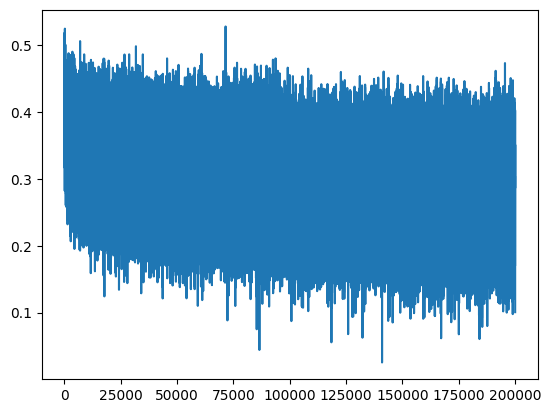

In [ ]:
# loss сильно колеблется между соседними итерациями
plt.plot(lossi)

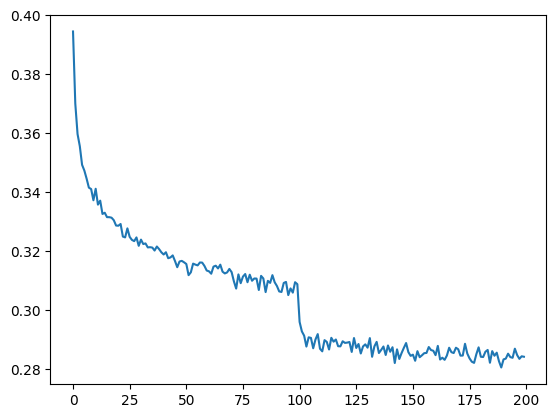

In [ ]:
# после того как уменьшили lr, произошёл скачок loss
# раньше, из-за большой lr, мы проскакивали нужное значение весов и средний loss был большой
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [ ]:
# мы считали running mean и running variance для того, чтобы при тестировании модели, если мы хотим предсказать 1 следующий символ
# мы брали более точное среднее, чем просто среднее из 1 элемента
# сейчас в слое batchnorm хотим использовать именно running mean и running variance, поэтому переключаем режим

In [ ]:
for layer in model.layers:
    layer.training = False

In [ ]:
@torch.no_grad()
def split_loss(split):
  x, y = {'train' : (Xtr, Ytr),
          'dev' : (Xdev, Ydev),
          'test' : (Xte, Yte)}[split]
  logits = model(x)
  print(f"{split} loss ", F.cross_entropy(logits, y))

split_loss('train')
split_loss('test')

train loss  tensor(1.9002)
test loss  tensor(2.0023)


In [ ]:
for i in range(20):
  word = ""
  symb = [0] * block_size
  while True:
    x = torch.tensor(symb).view((1, block_size))
    logits = model(x)
    probs = F.softmax(logits, dim=1)
    pos = torch.multinomial(probs, num_samples=1).item()
    if pos == 0:
      break
    else:
      word += chr(pos + ord('a') - 1)
      symb.append(pos)
      symb = symb[1:]
  print(word)

silianyen
jahden
remera
khanyli
surentane
mave
imana
thepn
azaya
jerson
madmae
ailani
illey
deniola
araan
juan
mareyah
bera
emigra
harshan


In [ ]:
for x, y in zip(Xtr[7:15], Ytr[7:15]):
  print(''.join(itos[ix.item()] for ix in x), '--->', itos[y.item()])

........ ---> d
.......d ---> i
......di ---> o
.....dio ---> n
....dion ---> d
...diond ---> r
..diondr ---> e
.diondre ---> .


In [ ]:
# Xtr[[7]], чтобы размер тензора был 1 на 8, а не просто 8
# по аналогии с Xtr[[2, 7, 1, 4]] - лист из индексов
logits = model(Xtr[[7]])

In [ ]:
logits = torch.zeros(8, 27)
for i in range(8):
  logits[i] = model(Xtr[[7 + i]])
logits.shape

torch.Size([8, 27])